# MainQuest01: 트랜스포머 구조 변경해서 GPT-1 만들기

## Transformer와 비교해 변경이 필요한 부분
1. 데이터 전처리 부분에서 트랜스포머에서는 토크나이저에 특수 토큰을 pad(0), unk(1), bos(2), eos(3)으로 했었는데 구분자 토큰[SEP]을 추가해야함.
2. 데이터 셋 변경: 트랜스포머에서는 인코더 인풋([BOS] + 질문 + [EOS]), 디코더 인풋([BOS] + 답변), target(답변 + [EOS])으로 했었는데, GPT-1에서는 디코더만 사용하기 때문에 하나의 시퀀스([BOS] + 질문 + [SEP] + 답변 + [EOS])를 사용하고, 인풋은 마지막 토큰 제외, 아웃풋은 첫 토큰 제외하는 데이터 셋을 만든다.
3. 인코더 전체 삭제: GPT-1은 디코더만 사용하는 구조이므로, 기존 Transformer의 인코더 블록 전체를 제거한다.
4. 디코더의 크로스 어텐션 제거: 인코더가 없으므로 인코더 출력을 참조하는 크로스 어텐션(인코더-디코더 어텐션) 서브레이어도 제거한다.
5. Positional Encoding → 학습 가능한 위치 임베딩: 원본 Transformer의 사인/코사인 고정 위치 인코딩을 nn.Embedding으로 교체한다. 논문 식 2의 Wₚ에 해당하며, 훈련 과정에서 함께 학습된다.

## STEP 1: 데이터 수집하기(트랜스포머와 동일)

In [1]:
# 데이터 확인하기
import pandas as pd

df = pd.read_csv('data/ChatbotData.csv')
print(df.head())  # 상위 5개 확인
print(df.shape)   # (행 수, 열 수) 확인
print(df.columns) # 컬럼명 확인

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
(11823, 3)
Index(['Q', 'A', 'label'], dtype='object')


## STEP 2: 데이터 전처리하기(트랜스포머와 동일)

In [2]:
import re

def preprocess_sentence(sentence):
  # 양쪽 공백 제거
  sentence = sentence.strip()

  # 구두점(?.!,) 앞뒤에 공백 추가
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

  # 연속된 공백을 하나의 공백으로 변환
  sentence = re.sub(r'[" "]+', " ", sentence)

  # 한글, 영문, 숫자, 구두점(?.!,)을 제외한 모든 문자를 공백으로 대체
  sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)

  # 양쪽 공백 제거
  sentence = sentence.strip()
  return sentence

# Q, A 각각 전처리 적용
df['Q'] = df['Q'].apply(preprocess_sentence)
df['A'] = df['A'].apply(preprocess_sentence)

print(df.head())

                 Q             A  label
0          12시 땡 !   하루가 또 가네요 .      0
1      1지망 학교 떨어졌어    위로해 드립니다 .      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠 .      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠 .      0
4          PPL 심하네   눈살이 찌푸려지죠 .      0


In [3]:
# 결측값(빈 데이터) 확인
print(df.isnull().sum())

# 전처리 후 빈 문자열이 생겼는지 확인
print(df[df['Q'] == ''].shape)
print(df[df['A'] == ''].shape)

Q        0
A        0
label    0
dtype: int64
(0, 3)
(0, 3)


## STEP 3: SentencePiece 사용하기

In [4]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.2 MB/s eta 0:00:00a 0:00:01


In [5]:
# 학습용 텍스트 파일 만들기
# Q와 A를 합쳐서 하나의 텍스트 파일로 저장
with open('chatbot_corpus.txt', 'w', encoding='utf-8') as f:
    for idx, row in df.iterrows():
        f.write(row['Q'] + '\n')
        f.write(row['A'] + '\n')

In [6]:
# SentencePiece 모델 학습
import sentencepiece as spm

spm.SentencePieceTrainer.Train(
    input='chatbot_corpus.txt',
    model_prefix='chatbot_sp',
    vocab_size=8000,
    model_type='bpe',
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    ########################################
    # 변경 필요한 부분 1번: 구분자 토큰 추가
    ########################################
    user_defined_symbols='[SEP]'  
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [SEP]
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enabl

In [7]:
# 학습된 모델 불러오기
sp = spm.SentencePieceProcessor()
sp.Load('chatbot_sp.model')

# 먼저 어떻게 토큰화되는지 테스트
print("토큰:", sp.EncodeAsPieces('3박4일 놀러가고 싶다'))
print("ID:", sp.EncodeAsIds('3박4일 놀러가고 싶다'))

토큰: ['▁3', '박', '4', '일', '▁놀러가고', '▁싶다']
ID: [476, 7437, 7404, 6979, 3494, 202]


In [8]:
# Q, A 전체를 숫자 ID로 토큰화
df['Q_tokenized'] = df['Q'].apply(lambda x: sp.EncodeAsIds(x))
df['A_tokenized'] = df['A'].apply(lambda x: sp.EncodeAsIds(x))

print(df[['Q', 'Q_tokenized', 'A', 'A_tokenized']].head())

                 Q                              Q_tokenized             A  \
0          12시 땡 !                  [5554, 6971, 3203, 109]   하루가 또 가네요 .   
1      1지망 학교 떨어졌어            [348, 6938, 7244, 1010, 2457]    위로해 드립니다 .   
2     3박4일 놀러가고 싶다       [476, 7437, 7404, 6979, 3494, 202]  여행은 언제나 좋죠 .   
3  3박4일 정도 놀러가고 싶다  [476, 7437, 7404, 6979, 984, 3494, 202]  여행은 언제나 좋죠 .   
4          PPL 심하네          [6929, 7915, 7915, 1, 316, 484]   눈살이 찌푸려지죠 .   

                              A_tokenized  
0                    [4487, 215, 5924, 5]  
1                         [1619, 6410, 5]  
2                    [5126, 1359, 383, 5]  
3                    [5126, 1359, 383, 5]  
4  [212, 4714, 2061, 7568, 7006, 4070, 5]  


In [9]:
# 테스트 하기
sentence = "3박4일 really 놀러가고 싶다..."
sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (서브워드 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 3박4일 really 놀러가고 싶다 . . .
Tokenized: ['▁3', '박', '4', '일', '▁', 're', 'a', 'lly', '▁놀러가고', '▁싶다', '▁.', '▁.', '▁.']
Encoded: [476, 7437, 7404, 6979, 6929, 1, 7810, 1, 3494, 202, 5, 5, 5]
Decoded: 3박4일  ⁇ a ⁇  놀러가고 싶다 . . .


In [16]:
# 토큰 길이 측정하기
import numpy as np

# Q, A 각각 토큰 길이 확인
q_lengths = df['Q'].apply(lambda x: len(sp.EncodeAsIds(x)))
a_lengths = df['A'].apply(lambda x: len(sp.EncodeAsIds(x)))

print("=== Q (질문) ===")
print(f"평균: {q_lengths.mean():.2f}")
print(f"표준편차: {q_lengths.std():.2f}")
print(f"최대: {q_lengths.max()}")
print(f"최소: {q_lengths.min()}")

print("\n=== A (답변) ===")
print(f"평균: {a_lengths.mean():.2f}")
print(f"표준편차: {a_lengths.std():.2f}")
print(f"최대: {a_lengths.max()}")
print(f"최소: {a_lengths.min()}")

=== Q (질문) ===
평균: 5.38
표준편차: 2.41
최대: 21
최소: 1

=== A (답변) ===
평균: 5.77
표준편차: 2.53
최대: 29
최소: 1


In [11]:
# GPT-1에서 쓸 토큰 길이 측정하기
import numpy as np

lengths = []
for idx, row in df.iterrows():
    q_ids = sp.EncodeAsIds(row['Q'])
    a_ids = sp.EncodeAsIds(row['A'])
    # BOS + Q + SEP + A + EOS
    total = 1 + len(q_ids) + 1 + len(a_ids) + 1
    lengths.append(total)

print(f"평균: {np.mean(lengths):.1f}")
print(f"최대: {np.max(lengths)}")
print(f"99%: {np.percentile(lengths, 99):.0f}")

평균: 14.1
최대: 43
99%: 25


In [13]:
###########################################################################
# 변경 필요한 부분 2번: 디코더 기반의 생성모델 전용으로 데이터 셋 만들어주기
###########################################################################

# Dataset 클래스 만들기 -> 데이터를 정리하고 하나씩 꺼내주는 역할
from torch.utils.data import Dataset, DataLoader
import torch

class ChatbotDataset(Dataset):
    def __init__(self, df, sp, max_length=30):
        self.data = []
        bos_id = sp.bos_id()
        eos_id = sp.eos_id()
        sep_id = sp.PieceToId('[SEP]')

        for idx, row in df.iterrows():
            q_ids = sp.EncodeAsIds(row['Q'])
            a_ids = sp.EncodeAsIds(row['A'])

            # 하나의 시퀀스로 합치기
            tokens = [bos_id] + q_ids + [sep_id] + a_ids + [eos_id]

            # 길이 제한
            if len(tokens) > max_length:
                continue

            # 패딩
            tokens += [0] * (max_length - len(tokens))

            # 입력과 타겟 분리 (한 칸 밀림)
            input_ids = tokens[:-1]
            target_ids = tokens[1:]

            self.data.append({
                "input": input_ids,
                "target": target_ids
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (
            torch.tensor(sample["input"], dtype=torch.long),
            torch.tensor(sample["target"], dtype=torch.long)
        )

In [14]:
# Dataset 생성
dataset = ChatbotDataset(df, sp, max_length=30)
print(f"전체 데이터 수: {len(dataset)}")

# DataLoader 생성
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 데이터 확인
for input_ids, target_ids in dataset:
    print("input 크기:", input_ids.size())
    print("input:", input_ids)
    print("input 디코딩:", sp.decode(input_ids.tolist()))
    print()
    print("target:", target_ids)
    print("target 디코딩:", sp.decode(target_ids.tolist()))
    break

전체 데이터 수: 11809
input 크기: torch.Size([29])
input: tensor([   2, 5554, 6971, 3203,  109,    4, 4487,  215, 5924,    5,    3,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0])
input 디코딩: 12시 땡 ![SEP] 하루가 또 가네요 .

target: tensor([5554, 6971, 3203,  109,    4, 4487,  215, 5924,    5,    3,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0])
target 디코딩: 12시 땡 ![SEP] 하루가 또 가네요 .


In [15]:
for input_ids, target_ids in dataloader:
    print(input_ids.size())
    print(target_ids.size())
    break

torch.Size([32, 29])
torch.Size([32, 29])


---
## STEP 4: 모델 구성하기(기존 코드에서 안쓰는 부분은 주석처리하고 추가하는 부분은 주석으로 표시하겠습니다)

### (1) Positional Encoding -> 삭제하고 nn.Embedding으로 교체.

In [20]:
import torch.nn as nn

# # Positional Encoding 
# class PositionalEncoding(nn.Module):
#     def __init__(self, position, d_model):
#         super(PositionalEncoding, self).__init__()
#         self.d_model = d_model
#         self.position = position

#         self.pos_encoding = self._build_pos_encoding(position, d_model)

#     def _get_angles(self, position, i, d_model):
#         return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

#     def _build_pos_encoding(self, position, d_model):
#         pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
#         i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

#         angle_rads = self._get_angles(pos, i, d_model)
#         sines = torch.sin(angle_rads[:, 0::2])
#         cosines = torch.cos(angle_rads[:, 1::2])

#         pos_encoding = torch.zeros(position, d_model)
#         pos_encoding[:, 0::2] = sines
#         pos_encoding[:, 1::2] = cosines

#         pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
#         return pos_encoding

#     def forward(self, x):
#         return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

---
### (2) Scaled dot product Attention
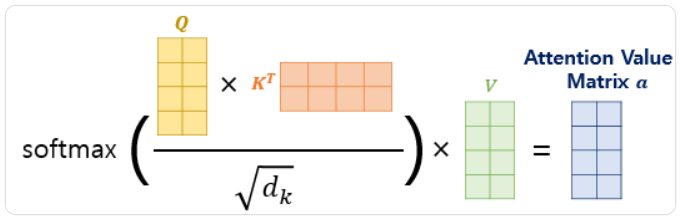

In [21]:
import math
import torch.nn.functional as F

def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

---
### (3) Multi-head Self Attention
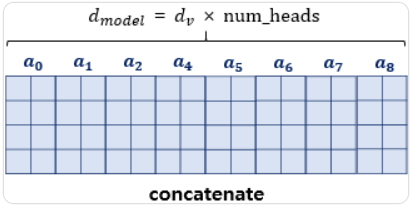
1. Linear 통과 -> Q, K, V 각각 가중치 곱해서 변환
2. split_head -> d_model을 num_heads로 나눠서 여러 관점으로 분리
3. scaled_dot_product_attention -> 어텐션 연산
4. 다시 합치기
5. 최종 Linear 연산

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


---
### (4) 마스킹
1. create_padding_mask — 패딩(0) 위치를 마스킹
2. create_look_ahead_mask — 미래 단어를 못 보게 마스킹

In [23]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [24]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

---
### (5) 인코더 -> 전체 삭제

In [25]:
###########################################################################
# 변경 필요한 부분 3번: 인코더 부분 전체 삭제
###########################################################################

# class EncoderLayer(nn.Module):
#     def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
#         super(EncoderLayer, self).__init__()
#         self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
#         self.dropout1 = nn.Dropout(dropout)
#         self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

#         # 피드포워드 부분 (Dense -> ReLU -> Dense)
#         self.ffn = nn.Sequential(
#             nn.Linear(d_model, ff_dim),
#             nn.ReLU(),
#             nn.Linear(ff_dim, d_model)
#         )
#         self.dropout2 = nn.Dropout(dropout)
#         self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

#     def forward(self, x, mask=None):
#         # (1) 멀티 헤드 어텐션 (셀프 어텐션)
#         attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
#         attn_output = self.dropout1(attn_output)
#         out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

#         # (2) 피드포워드 신경망
#         ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
#         ffn_output = self.dropout2(ffn_output)
#         out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

#         return out2


In [26]:
# class Encoder(nn.Module):
#     def __init__(self,
#                  vocab_size,
#                  num_layers,
#                  ff_dim,
#                  d_model,
#                  num_heads,
#                  dropout=0.1):
#         super(Encoder, self).__init__()
#         self.d_model = d_model

#         # (1) 임베딩 레이어
#         self.embedding = nn.Embedding(vocab_size, d_model)

#         # (2) 포지셔널 인코딩
#         self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

#         self.dropout = nn.Dropout(dropout)

#         # (3) EncoderLayer 쌓기
#         self.enc_layers = nn.ModuleList([
#             EncoderLayer(d_model, num_heads, ff_dim, dropout)
#             for _ in range(num_layers)
#         ])

#     def forward(self, x, mask=None):
#         # (1) 임베딩 & sqrt(d_model)로 스케일링
#         x = self.embedding(x) * math.sqrt(self.d_model)

#         # (2) 포지셔널 인코딩 적용 + 드롭아웃
#         x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
#         x = self.dropout(x)

#         # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
#         for layer in self.enc_layers:
#             x = layer(x, mask)

#         return x

---
### (6) 디코더
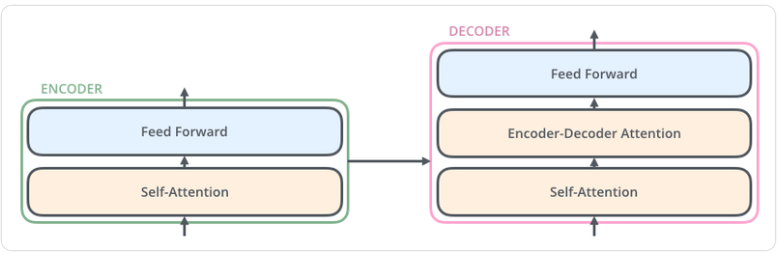

In [27]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        ###########################################################################
        # 변경 필요한 부분 4번: 디코더의 크로스 어텐션 레이어 제거
        ###########################################################################
        
        # # 두 번째 서브 레이어 (인코더-디코더 어텐션) -> 삭제
        # self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        # self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, look_ahead_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        ###########################################################################
        # 변경 필요한 부분 4번: 디코더의 크로스 어텐션 레이어 제거
        ###########################################################################
        
        # # 2) 인코더-디코더 어텐션
        # encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        # encdec_attn_out = self.dropout2(encdec_attn_out)
        # out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out1 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [51]:
###########################################################################
# 변경 필요한 부분 5번: PositionalEncoding → nn.Embedding으로 교체
# 변경 필요한 부분 4번: 디코더의 크로스 어텐션 레이어 제거
###########################################################################

class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 max_length=30,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # # (2) 포지셔널 인코딩 -> 제거!!!
        # # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        # self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        # (2) 학습 가능한 위치 임베딩으로 변경 (GPT-1 방식)
        self.pos_embedding = nn.Embedding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # # (2) 포지셔널 인코딩 + 드롭아웃 -> 제거!!!
        # x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        # x = self.dropout(x)

        # (2) 위치 임베딩 추가
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = x + self.pos_embedding(positions)
        x = self.dropout(x)
        
        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, mask)

        return x

---
### (7) 모델 정의 및 학습하기
앞에서 사용한 인코더 층 함수와 디코더 층 함수를 사용하여 트랜스포머 함수를 정의한다.

In [79]:
###########################################################################
# 변경 필요한 부분 3번: 인코더 부분 제거
# 변경 필요한 부분 4번: 디코더의 크로스 어텐션 레이어 제거
###########################################################################

class GPT_1(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(GPT_1, self).__init__()

        # # 인코더 -> 삭제
        # self.encoder = Encoder(
        #     vocab_size=vocab_size,
        #     num_layers=num_layers,
        #     ff_dim=units,
        #     d_model=d_model,
        #     num_heads=num_heads,
        #     dropout=dropout
        # )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs):
        # # 1) 인코더 패딩 마스크 생성
        # enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        # dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # # 4) 인코더 수행
        # enc_outputs = self.encoder(
        #     x=inputs,
        #     mask=enc_padding_mask
        # )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=inputs,           # (batch_size, tgt_seq_len)
            mask=look_ahead_mask
        )

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [80]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = sp.GetPieceSize() # 단어 집합 크기

# 모델 생성
model = GPT_1(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

GPT_1(
  (decoder): Decoder(
    (embedding): Embedding(8000, 256)
    (pos_embedding): Embedding(30, 256)
    (dropout): Dropout(p=0.1, inplace=False)
    (dec_layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm3): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout3): Dropout(p=0.1, inplace

In [81]:
# 손실함수
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [82]:
# 커스텀 된 학습률
def get_lr_lambda(d_model, warmup_steps=1000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [83]:
import torch.optim as optim
from torch.optim import lr_scheduler

# 모델 컴파일
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [84]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [85]:
# 학습하기
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    input_ids, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스 (입력 하나만)
    logits = model(input_ids)

    # loss 계산
    logits = logits.view(-1, logits.size(-1))
    target = target.view(-1)
    loss = loss_function(logits, target)

    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

In [86]:
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=100,  # 원하는 에폭 수
    device=device
)

[Epoch 1, Step 0] Loss: 9.1255, Acc: 0.0000
[Epoch 1, Step 100] Loss: 7.0918, Acc: 0.1759
[Epoch 1, Step 200] Loss: 6.2808, Acc: 0.2457
[Epoch 1, Step 300] Loss: 6.1457, Acc: 0.2237
Epoch 1 Completed - Avg Loss: 6.8063, Avg Acc: 0.1993
[Epoch 2, Step 0] Loss: 6.0226, Acc: 0.2253
[Epoch 2, Step 100] Loss: 5.8006, Acc: 0.2475
[Epoch 2, Step 200] Loss: 5.6434, Acc: 0.2437
[Epoch 2, Step 300] Loss: 5.4983, Acc: 0.2489
Epoch 2 Completed - Avg Loss: 5.5997, Avg Acc: 0.2581
[Epoch 3, Step 0] Loss: 4.8880, Acc: 0.3030
[Epoch 3, Step 100] Loss: 4.5855, Acc: 0.3342
[Epoch 3, Step 200] Loss: 4.9054, Acc: 0.2740
[Epoch 3, Step 300] Loss: 4.7631, Acc: 0.2987
Epoch 3 Completed - Avg Loss: 4.8883, Avg Acc: 0.2862
[Epoch 4, Step 0] Loss: 3.9883, Acc: 0.3793
[Epoch 4, Step 100] Loss: 4.3322, Acc: 0.3194
[Epoch 4, Step 200] Loss: 4.2129, Acc: 0.3083
[Epoch 4, Step 300] Loss: 4.6803, Acc: 0.3139
Epoch 4 Completed - Avg Loss: 4.2922, Avg Acc: 0.3145
[Epoch 5, Step 0] Loss: 3.6948, Acc: 0.3626
[Epoch 5, St

## STEP 5: 모델 평가하기

In [88]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    SEP_TOKEN = tokenizer.PieceToId('[SEP]')
    MAX_LENGTH = 29  # max_length(30) - 1 (학습 시 input이 29였으므로)

    # 전처리
    sentence = preprocess_sentence(sentence)

    # 입력 시퀀스: [BOS] + 질문 + [SEP]
    input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [SEP_TOKEN]
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        for i in range(MAX_LENGTH - len(input_ids)):
            # 모델에 현재 시퀀스 전체를 넣음
            logits = model(input_tensor)

            # 마지막 위치의 예측만 추출
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 예측 토큰을 시퀀스에 이어붙임
            predicted_id = predicted_id.unsqueeze(0)
            input_tensor = torch.cat([input_tensor, predicted_id], dim=1)

    # [SEP] 이후 부분만 추출 (답변 부분)
    output_sequence = input_tensor.squeeze(0).tolist()
    
    return output_sequence

In [93]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # [SEP] 이후 부분만 추출 (답변 부분)
    sep_id = tokenizer.PieceToId('[SEP]')
    if sep_id in output_seq:
        sep_idx = output_seq.index(sep_id)
        answer_ids = output_seq[sep_idx + 1:]
    else:
        answer_ids = output_seq

    # 특수 토큰 제거 후 디코딩
    answer_ids = [t for t in answer_ids if t not in [tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.pad_id()]]
    predicted_sentence = tokenizer.decode(answer_ids)

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [94]:
test_sentences = [
    "오늘 날씨 어때?",
    "밥 먹었어?",
    "사랑",
    "기분이 너무 안 좋아",
    "심심해",
    "고",
    "학교 가기 싫다",
    "좋은 아침",
    "3박4일 놀러가고 싶다",
    "잠이 안 와",
]

for sent in test_sentences:
    sentence_generation(model, sent, sp, device=device)
    print("-" * 50)

입력 : 오늘 날씨 어때?
출력 : 하늘을 보고 웃어보세요 .
--------------------------------------------------
입력 : 밥 먹었어?
출력 : 저는 배터리가 밥이예요 .
--------------------------------------------------
입력 : 사랑
출력 : 항상 꿈 꾸죠 .
--------------------------------------------------
입력 : 기분이 너무 안 좋아
출력 : 무슨 일이 있었나봐요 .
--------------------------------------------------
입력 : 심심해
출력 : 친구들과 연락해보세요 .
--------------------------------------------------
입력 : 고
출력 : 다이어트하기 기다려줄 알았는데 .
--------------------------------------------------
입력 : 학교 가기 싫다
출력 : 학교 다닐 때가 좋은 거예요 .
--------------------------------------------------
입력 : 좋은 아침
출력 : 좋은 아침이에요 .
--------------------------------------------------
입력 : 3박4일 놀러가고 싶다
출력 : 여행은 언제나 좋죠 .
--------------------------------------------------
입력 : 잠이 안 와
출력 : 양을 세어 보아요 .
--------------------------------------------------
